# Control de Calidad de Dosis de Radiación en LINAC

Este notebook simula y analiza datos de control de calidad para un acelerador lineal médico (LINAC). Se generan 500 registros diarios con dosis medidas, temperatura y presión, y se evalúan desviaciones con respecto a los límites clínicos establecidos.

**Librerías utilizadas:** `pandas`, `numpy`, `matplotlib`, `seaborn`

## 1. Generación del Dataset Sintético

Se genera un dataset simulado con 500 registros diarios a partir del 1 de enero de 2025. Cada registro incluye:

- **`Fecha`**: fechas consecutivas con frecuencia diaria
- **`Dosis_Medida`**: dosis simulada con distribución normal (media=2.0 Gy, σ=0.04 Gy)
- **`Dosis_Objetivo`**: valor de referencia constante de 2.0 Gy
- **`Temperatura`**: temperatura ambiental de la sala (18–24 °C), distribución uniforme
- **`Presion_hPa`**: presión atmosférica (980–1030 hPa), distribución uniforme

> Se fija una semilla aleatoria (`np.random.seed(42)`) para garantizar reproducibilidad.

In [8]:
import pandas as pd   #Herramienta para tratar datos
import numpy as np #       "     calculo numerico
import matplotlib.pyplot as plt

# Configuramos la semilla aleatoria para que tus resultados y los míos sean idénticos
np.random.seed(42)

# Creamos 500 registros
n_registros = 500

data = {
    'Fecha': pd.date_range(start='2025-01-01', periods=n_registros, freq='D'), #generamos fechas consecutivas iniciando en la fecha indicada con ese formato, periodism=cantidad de fechas a generar, frec=frecuenacia
    # Generamos dosis con una distribución normal: media 2.0 y pequeña desviación estándar
    'Dosis_Medida': np.random.normal(loc=2.0, scale=0.04, size=n_registros),
    'Dosis_Objetivo': 2.0,
    'Temperatura': np.random.uniform(18, 24, size=n_registros), # °C ambiente en sala random.uniform es para una distribucion uniforme/osilacion aleatoria
    'Presion_hPa': np.random.uniform(980, 1030, size=n_registros) # Presión atmosférica
}

df_linac = pd.DataFrame(data) #Tomamos el diccionario data y lo convertimos en el objeto Dataframe

# Visualizamos los primeros registros
print(df_linac.head())

       Fecha  Dosis_Medida  Dosis_Objetivo  Temperatura  Presion_hPa
0 2025-01-01      2.019869             2.0    21.875503  1023.592176
1 2025-01-02      1.994469             2.0    21.424670   981.462364
2 2025-01-03      2.025908             2.0    20.136580  1021.290838
3 2025-01-04      2.060921             2.0    23.919091   986.443493
4 2025-01-05      1.990634             2.0    21.634649   996.755943


## 2. Cálculo de la Desviación Porcentual

Se calcula la **desviación porcentual** de la dosis medida respecto a la dosis objetivo:

$$\text{Desviación (\%)} = \frac{\text{Dosis\_Medida} - \text{Dosis\_Objetivo}}{\text{Dosis\_Objetivo}} \times 100$$

In [3]:
df_linac['Desviacion_Porcentaje']=((df_linac['Dosis_Medida']-df_linac['Dosis_Objetivo'])/df_linac['Dosis_Objetivo'])*100

## 3. Detección de Alertas Clínicas

Se identifican los registros que superan el **límite de parada del ±3%**, es decir, aquellos días en que la desviación fue clínicamente inaceptable y requeriría intervención inmediata en un entorno real.

In [5]:
# Alertas
alertas = df_linac[(df_linac['Desviacion_Porcentaje'] > 3) | (df_linac['Desviacion_Porcentaje'] < -3)]

### Visualización del resultado de alertas

Se imprimen los registros que activaron la alerta de desviación mayor a ±3%.

In [6]:
print(alertas)

         Fecha  Dosis_Medida  Dosis_Objetivo  Temperatura  Presion_hPa  \
3   2025-01-04      2.060921             2.0    23.919091   986.443493   
6   2025-01-07      2.063169             2.0    18.610695   988.037995   
13  2025-01-14      1.923469             2.0    23.380593  1029.059309   
14  2025-01-15      1.931003             2.0    18.481402  1011.590676   
31  2025-02-01      2.074091             2.0    19.122262  1015.408604   
..         ...           ...             ...          ...          ...   
474 2026-04-20      2.065799             2.0    18.486277  1013.245586   
478 2026-04-24      2.123155             2.0    23.107241   999.965796   
482 2026-04-28      1.935742             2.0    22.948086  1006.997857   
488 2026-05-04      2.067486             2.0    22.784556   986.385674   
494 2026-05-10      2.060925             2.0    22.184829   993.155628   

     Desviacion_Porcentaje  
3                 3.046060  
6                 3.158426  
13               -3.8265

### Verificación de columnas del DataFrame

Revisión de las columnas disponibles en el DataFrame antes de continuar con el análisis.

In [12]:
print(df_linac.columns)

Index(['Fecha', 'Dosis_Medida', 'Dosis_Objetivo', 'Temperatura',
       'Presion_hPa'],
      dtype='object')


In [13]:
df_linac['Desviacion_Porcentaje'] = ((df_linac['Dosis_Medida'] - df_linac['Dosis_Objetivo']) / df_linac['Dosis_Objetivo']) * 100

## 4. Histograma de Errores del LINAC

Se visualiza la distribución de las desviaciones porcentuales a lo largo de los 500 días. Las líneas de referencia indican los umbrales clínicos:

- **Negro (0%)**: valor ideal sin error
- **Naranja (±2%)**: límite de advertencia
- **Rojo (±3%)**: límite de parada del equipo

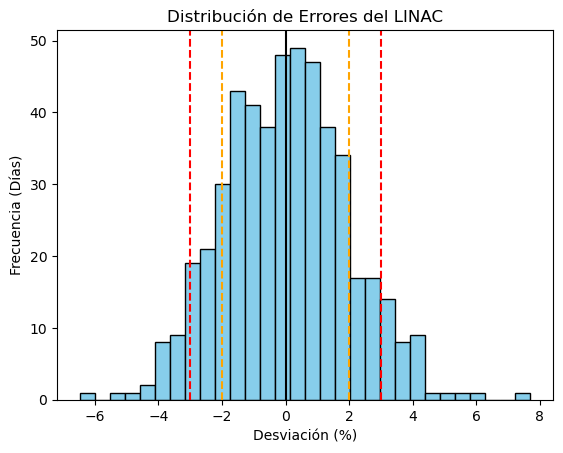

In [14]:
# Tu código original
plt.hist(df_linac['Desviacion_Porcentaje'], bins=30, color='skyblue', edgecolor='black')

# Añadimos elementos de referencia clínica
plt.axvline(0, color='black', linestyle='-')        # El ideal (0% error)
plt.axvline(2, color='orange', linestyle='--')     # Límite de advertencia +2%
plt.axvline(-2, color='orange', linestyle='--')    # Límite de advertencia -2%
plt.axvline(3, color='red', linestyle='--')        # Límite de parada +3%
plt.axvline(-3, color='red', linestyle='--')       # Límite de parada -3%

plt.title('Distribución de Errores del LINAC')
plt.xlabel('Desviación (%)')
plt.ylabel('Frecuencia (Días)')
plt.show()

## 5. Estadísticas Descriptivas de la Desviación

Se obtienen las estadísticas básicas (media, desviación estándar, percentiles) de la columna `Desviacion_Porcentaje` para evaluar el comportamiento general del LINAC.

In [16]:
df_linac['Desviacion_Porcentaje'].describe()

count    500.000000
mean       0.013676
std        1.962506
min       -6.482535
25%       -1.400615
50%        0.025594
75%        1.273567
max        7.705463
Name: Desviacion_Porcentaje, dtype: float64

## 6. Corrección por Temperatura y Presión (Factor KTP)

En dosimetría clínica, la dosis medida se corrige usando el **Factor KTP** (Kelvin-Temperatura-Presión), que ajusta la lectura del detector según las condiciones ambientales:

$$K_{TP} = \frac{273.15 + T}{273.15 + 22} \times \frac{1013.25}{P}$$

Donde:
- **T**: temperatura ambiental medida (°C)
- **P**: presión atmosférica medida (hPa)
- **22 °C** y **1013.25 hPa**: condiciones de referencia estándar

In [17]:
df_linac['Factor_KTP']=((273.15 + df_linac["Temperatura"])/(273.15+22)*(1013.25/df_linac["Presion_hPa"]))

### Cálculo de Dosis Corregida y Desviación Corregida

Se aplica el Factor KTP a la dosis medida para obtener la **dosis corregida**, y se recalcula la desviación porcentual con esta corrección.

In [18]:
df_linac["Dosis_Corregida"]=(df_linac["Dosis_Medida"])*(df_linac["Factor_KTP"])
df_linac["Desviacion_Corregida"] =  ((df_linac['Dosis_Corregida'] - df_linac['Dosis_Objetivo']) / df_linac['Dosis_Objetivo']) * 100


## 7. Comparación de Precisión: Original vs. Corregida

Se compara la desviación estándar de la desviación original frente a la corregida. Una menor desviación estándar indica mayor precisión dosimétrica.

In [19]:
print("Precisión Original (std):", df_linac['Desviacion_Porcentaje'].std())
print("Precisión Corregida (std):", df_linac['Desviacion_Corregida'].std())


Precisión Original (std): 1.962506494723707
Precisión Corregida (std): 2.489565183899005


## 8. Boxplot Comparativo: Dispersión Original vs. Corregida

Se visualiza mediante un **boxplot** la dispersión de ambas métricas:

- `Desviacion_Porcentaje`: desviación sin corrección ambiental
- `Desviacion_Corregida`: desviación con corrección KTP

Las líneas horizontales rojas representan los límites clínicos de ±3%.

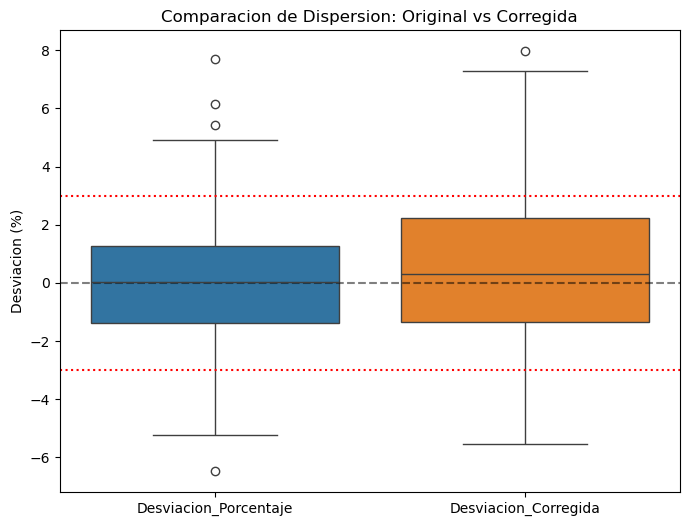

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

columnas_a_comparar = ["Desviacion_Porcentaje","Desviacion_Corregida"]

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_linac[columnas_a_comparar])
plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.axhline(3, color="red", linestyle=":", label="Limite +3%")
plt.axhline(-3, color="red", linestyle=":", label="Limite -3%")
plt.title("Comparacion de Dispersion: Original vs Corregida")
plt.ylabel("Desviacion (%)")
plt.show()